# CAB420, Metric Learning, Example 2: Contrastive Loss
Dr Simon Denman (s.denman@qut.edu.au)

## Overview
In this example we will continue our exploration of Siamese networks. Our first Siamese Network used binary cross entropy. This worked ok for telling us if things were the same, or different, but didn't really say how similar or how different things are. Often in machine learning, we'd like to rank things by similarity. For example, consider a biometrics scenario. We might want to find a suspect in CCTV, but rather than check if each and every person is the one we're after, it makes more sense to return the best $N$ matches. However to do this, we need a way to quantify how similar things are. This is where contrastive loss comes in.

This example is going to repeat a fair bit of code from the CAB420_Metric_Learning_Ex1_SiameseNetworks demo, so if you haven't looked at that example, please do so before diving into this one.

## Too Long; Didn't Read:
* Contrastive loss allows us to specify how much closer similar pairs of images should be than dissimilar pairs
* This allows us to increase the distance between similar and dissimilar, and provides an embedding that can be used to rank items
* We can use normalisation of the embedding to make it easier to set the margin

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import random
import numpy
import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# for consistency
random.seed(4)

E0000 00:00:1768953115.858524   12704 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768953115.862468   12704 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768953115.873493   12704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768953115.873509   12704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768953115.873512   12704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768953115.873514   12704 computation_placer.cc:177] computation placer already registered. Please check linka

## The Data

This is the same as Metric Learning, Example 1. See there for more info as to what's going on.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# create a hold-out validation set
num_train_samples = 50000
x_val = x_train[num_train_samples:, :]
y_val = y_train[num_train_samples:]
x_train = x_train[0:num_train_samples, :]
y_train = y_train[0:num_train_samples]

# reshape as needed
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1) / 255
y_train = y_train.reshape(y_train.shape[0], 1)
x_val = x_val.reshape(x_val.shape[0], 28, 28, 1) / 255
y_val = y_val.reshape(y_val.shape[0], 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1) / 255
y_test = y_test.reshape(y_test.shape[0], 1)

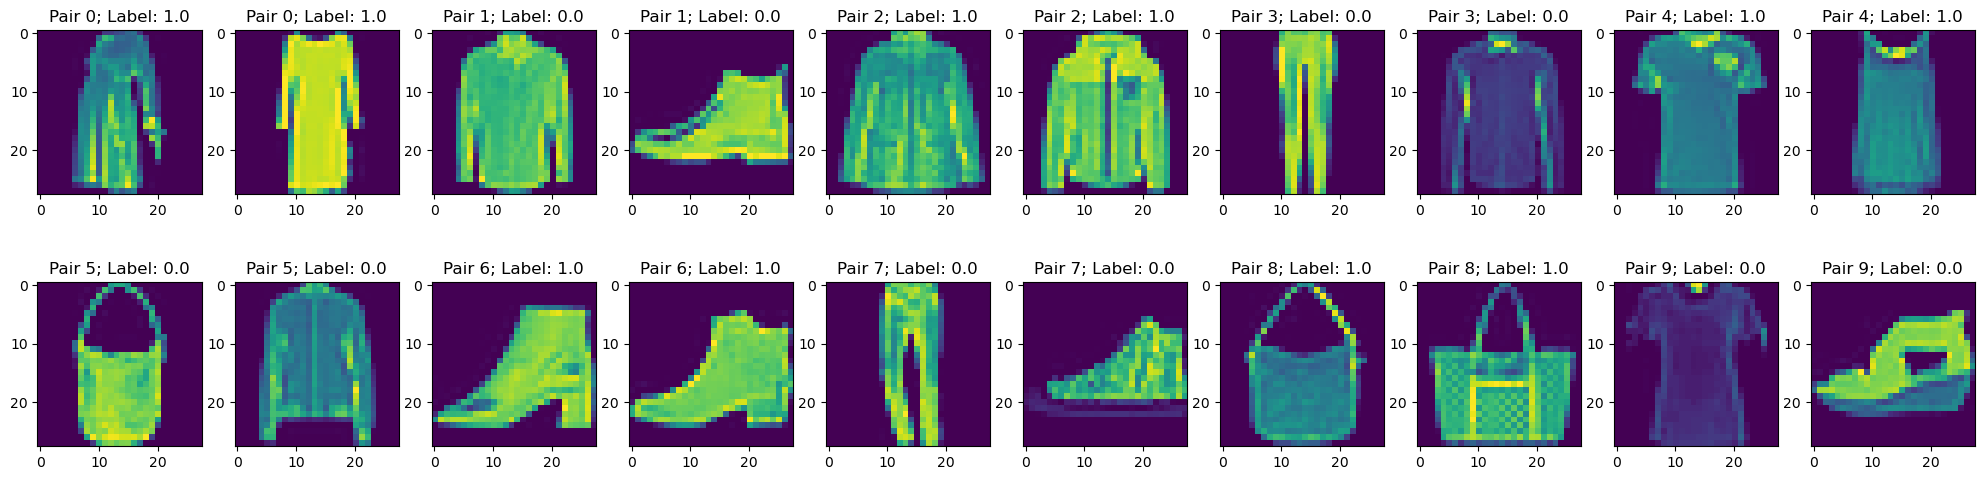

In [3]:
def GetSiameseData(imgs, labels, num_pairs):

    image_a = numpy.zeros((num_pairs, numpy.shape(imgs)[1], numpy.shape(imgs)[2], numpy.shape(imgs)[3]));
    image_b = numpy.zeros((num_pairs, numpy.shape(imgs)[1], numpy.shape(imgs)[2], numpy.shape(imgs)[3]));
    label = numpy.zeros(num_pairs);
    
    for i in range(num_pairs):
        
        if (i % 2 == 0):
            idx1 = random.randint(0, len(imgs) - 1)
            idx2 = random.randint(0, len(imgs) - 1)
            l = 1
            while (labels[idx1] != labels[idx2]):
                idx2 = random.randint(0, len(imgs) - 1)            
                
        else:
            idx1 = random.randint(0, len(imgs) - 1)
            idx2 = random.randint(0, len(imgs) - 1)
            l = 0
            while (labels[idx1] == labels[idx2]):
                idx2 = random.randint(0, len(imgs) - 1)

        image_a[i, :, :, :] = imgs[idx1,:,:,:]
        image_b[i, :, :, :] = imgs[idx2,:,:,:]
        label[i] = l

    return (image_a, image_b), label

def SiameseGenerator(imgs, labels, batch_size):
    while True:
        yield GetSiameseData(imgs, labels, batch_size)
        
x, y = GetSiameseData(x_train, y_train, 10)

fig = plt.figure(figsize=[25, 6])
for i in range(10):
    ax = fig.add_subplot(2, 10, i*2 + 1)
    ax.imshow(x[0][i,:,:,0])
    ax.set_title('Pair ' + str(i) +'; Label: ' + str(y[i]))
    
    ax = fig.add_subplot(2, 10, i*2 + 2)
    ax.imshow(x[1][i,:,:,0])    
    ax.set_title('Pair ' + str(i) +'; Label: ' + str(y[i]))            

## The Network
You'll get a sense of Deja Vu here too, as we're going to go with a pretty similar setup to last time. At least initially.

Once again, we'll use our VGG functions.

In [4]:
def conv_block(inputs, filters, spatial_dropout = 0.0, max_pool = True):
    
    x = layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if (spatial_dropout > 0.0):
        x = layers.SpatialDropout2D(spatial_dropout)(x)
    if (max_pool == True):
        x = layers.MaxPool2D(pool_size=(2, 2))(x)
    
    return x

def fc_block(inputs, size, dropout):
    x = layers.Dense(size, activation=None)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if (dropout > 0.0):
        x = layers.Dropout(dropout)(x)
    
    return x

def vgg_net(inputs, filters, fc, spatial_dropout = 0.0, dropout = 0.0):
    
    x = inputs
    for idx,i in enumerate(filters):
        x = conv_block(x, i, spatial_dropout, not (idx==len(filters) - 1))
    
    x = layers.Flatten()(x)
    
    for i in fc:
        x = fc_block(x, i, dropout)
        
    return x

Create the common branch here, as per last time:
* Create an input
* Create the network with our desired parameters
* Add an embedding layer
* Turn that into a model

In [5]:
embedding_size = 32
dummy_input = keras.Input((28, 28, 1))
base_network = vgg_net(dummy_input, [8, 16, 32], [256], 0.2, 0)
embedding_layer = layers.Dense(embedding_size, activation=None)(base_network)
base_network = keras.Model(dummy_input, embedding_layer, name='SiameseBranch')

I0000 00:00:1768953119.779492   12704 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:02:07.0, compute capability: 8.6


And now we use `base_network` to get our embeddings by:
* creating our two inputs
* passing each of these through the base_network

In [6]:
input_a = keras.Input((28, 28, 1), name='InputA')
input_b = keras.Input((28, 28, 1), name='InputB')

embedding_a = base_network(input_a)
embedding_b = base_network(input_b)

### New Stuff
Something different happens now.

In particular, what we want to do is get the distance between two vectors. We're going to use Euclidean distance, though Cosine distance would also be a valid choice here. Once we've got that, we'll use this distance to drive our contrastive loss.

#### Contrastive Loss

Let's quickly recap the maths here. First up we need to define a distance metric. Here we have the L2 (Euclidean) distance between our two features, $\bar{x}_1$ and $\bar{x}_2$:
$d_i = ||\bar{x}_1 - \bar{x}_2||_2$

We get $\bar{x}_1$ and $\bar{x}_2$ by passing our inputs, $x_1$ and $x_2$, through the base network. Using these, we can then compute our constrastive loss:

$L_{C} = \frac{1}{N}\sum_{i=1}^{N}y_i d_i + (1 - y_i)max(margin - d_i, 0)$

Here, $y_i$ is the label indicating if the two inputs, $x_1$ and $x_2$, belong to the same class. $y_i = 1$ if they belong to the same class. Remember that our network is trained to minimise the loss, so when $y_i = 1$, the second term in our loss, $(1 - y_i)max(margin - d_i, 0)$ goes to 0 and we focus on the first term, $y_i d_i$. Essentially, our network will seek to make $d_i$ as small as possible in these situations such that **if our two inputs are from the same class, the distance between them should be as small**.

When $y_i = 1$, the other term in the loss is active. This term is a little bit stranger to look at, $(1 - y_i)max(margin - d_i, 0)$, but basically what we want is $d_i \geq margin$. If $d_i \geq margin$, then $margin - d_i$ will be less than $0$ and $max(margin - d_i, 0)$ will return $0$. If $d_i < margin$, then we will have a positive loss value here. So this term aims to ensure that **when two inputs are from different classes, the distance between should be at least some value, $margin$**.

#### Implementing Contrastive Loss

Let's implement this now.

Note, the below is backbone agnostic and uses `keras.ops` to do the needed maths, however for whatever reason `keras.ops` does not have a vector normalise function. What we want to do is this,

$\hat{x} = \frac{x}{||x||}$,

where $\hat{x}$ is our normalised vector that we get by dividing the $x$ by it's magnitude,

$||x|| = \sqrt{\sum{x_{i}^{2}}}$,

i.e. the square root of the sum of the square of the elements. While that operation really isn't too hard, the fact that we have to consider that a batch of vectors are going into this make it a bit shit.

In [7]:
def normalise_vector(vect):
    # get the magnitude for each vector in the batch
    mag = keras.ops.sqrt(keras.ops.sum(keras.ops.square(vect), axis=1))
    # repeat this, so we now have as many elements in mag as we do in vect
    mag = keras.ops.reshape(keras.ops.repeat(mag, vect.shape[1], axis=0), (-1, vect.shape[1]))
    # element wise division
    return keras.ops.divide(vect, mag)

def euclidean_distance(vects):
    x, y = vects
    x = normalise_vector(x) # this is just doing x = tf.math.l2_normalize(x, axis=1)
    y = normalise_vector(y) # this is just doing y = tf.math.l2_normalize(y, axis=1)

    sum_square = keras.ops.sum(keras.ops.square(keras.ops.subtract(x, y)), axis=1, keepdims=True)
    return keras.ops.sqrt(keras.ops.maximum(sum_square, keras.config.epsilon()))

def eucl_dist_output_shape(shapes):
    shape1, shape2 = shapes
    return (shape1[0], 1)

def contrastive_loss(y_true, y_pred):
    '''Contrastive loss from Hadsell-et-al.'06
    http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
    '''
    margin = 1
    square_pred = keras.ops.square(y_pred)
    margin_square = keras.ops.square(keras.ops.maximum(margin - y_pred, 0))
    return keras.ops.mean(y_true * square_pred + (1 - y_true) * margin_square)

Now we add a layer to calculate the euclidean distance between the two embeddings, and then build our model

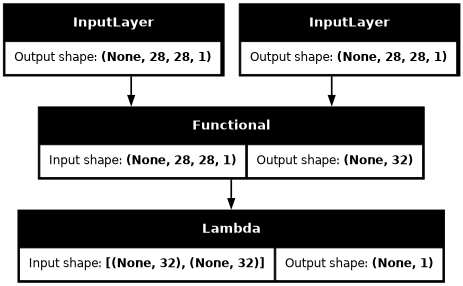

In [8]:
distance = layers.Lambda(euclidean_distance,
                  output_shape=eucl_dist_output_shape)([embedding_a, embedding_b])

siamese_network = keras.Model([input_a, input_b], distance)
# note that I've got expand_nested=False here. If you want to see the full network set this to True.
keras.utils.plot_model(siamese_network, show_shapes=True, dpi = 60, expand_nested=False)

In [9]:
# note I'm selecting no metrics here, accuracy doesn't make sense for the way that we're training the model
siamese_network.compile(loss=contrastive_loss, optimizer=keras.optimizers.Adam(), metrics=[], jit_compile=False)

Training and testing setup is as per the last example.

Note that as per the last example, the use of a fixed set of pairs here is sub-optimal. Contrastive loss is better, so overall this example is a step in the right direction, but we could do the data creation aspect better. As per the last example, we're keeping it simpler here as data creation is not the main focus, but if you're interested have a look at the bonus examples that show better ways to approach this.

In [10]:
batch_size = 128
siamese_generator = SiameseGenerator(x_train, y_train, batch_size)
siamese_val_x, siamese_val_y = GetSiameseData(x_val, y_val, 10000)
siamese_test_x, siamese_test_y = GetSiameseData(x_test, y_test, 10000)

siamese_network.fit(siamese_generator, steps_per_epoch=50000//batch_size, epochs=10, validation_data = (siamese_val_x, siamese_val_y))

Epoch 1/10


E0000 00:00:1768953122.920827   12704 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/SiameseBranch_3/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768953123.466863   12749 cuda_dnn.cc:529] Loaded cuDNN version 90300


390/390 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1224 - val_loss: 0.0845
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0844 - val_loss: 0.0735
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0753 - val_loss: 0.0669
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0698 - val_loss: 0.0637
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0653 - val_loss: 0.0613
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0627 - val_loss: 0.0585
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0593 - val_loss: 0.0564
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0578 - val_loss: 0.0550
Epoch 9/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0557 - val_loss: 0.0545
Epoch 10/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0536 - val_loss: 0.0523


# The Results
Let's have a look at some outputs.

We'll start with just a random 10 samples and see what it returns. For extra info, we'll plot the raw score out of the network rather than the rounded result, and show the expected score in brackets.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


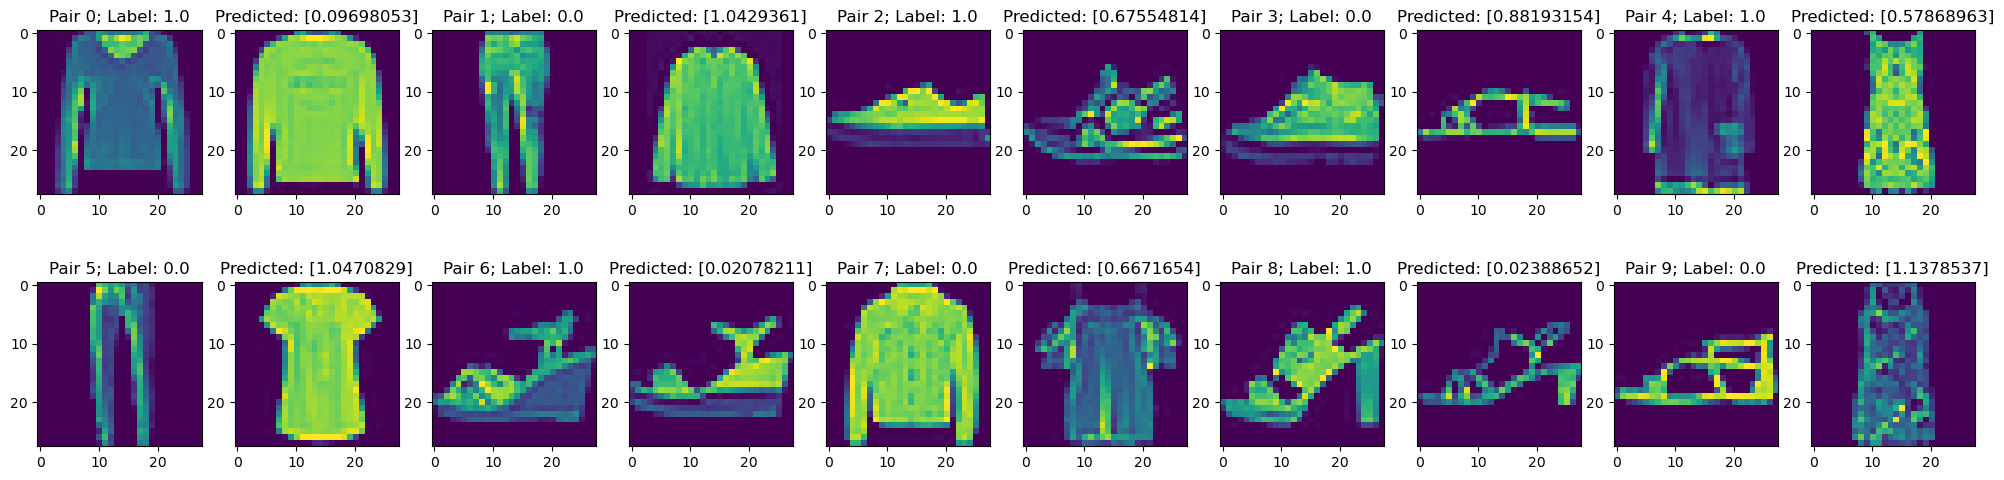

In [11]:
x, y = GetSiameseData(x_test, y_test, 10)
res = siamese_network.predict(x)

fig = plt.figure(figsize=[25, 6])
for i in range(10):
    ax = fig.add_subplot(2, 10, i*2 + 1)
    ax.imshow(x[0][i,:,:,0])
    ax.set_title('Pair ' + str(i) +'; Label: ' + str(y[i]))
    
    ax = fig.add_subplot(2, 10, i*2 + 2)
    ax.imshow(x[1][i,:,:,0])    
    ax.set_title('Predicted: ' + str(res[i]))

These results look, on the whole, pretty good. Similar objects are close, dissimilar objects are far away. But all is not perfect. Consider the second and fifth pairs - where the dissimilar pair (pair 1) are closer than the similar pair (pair 4).

Looking at things with a constant first image we get this:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


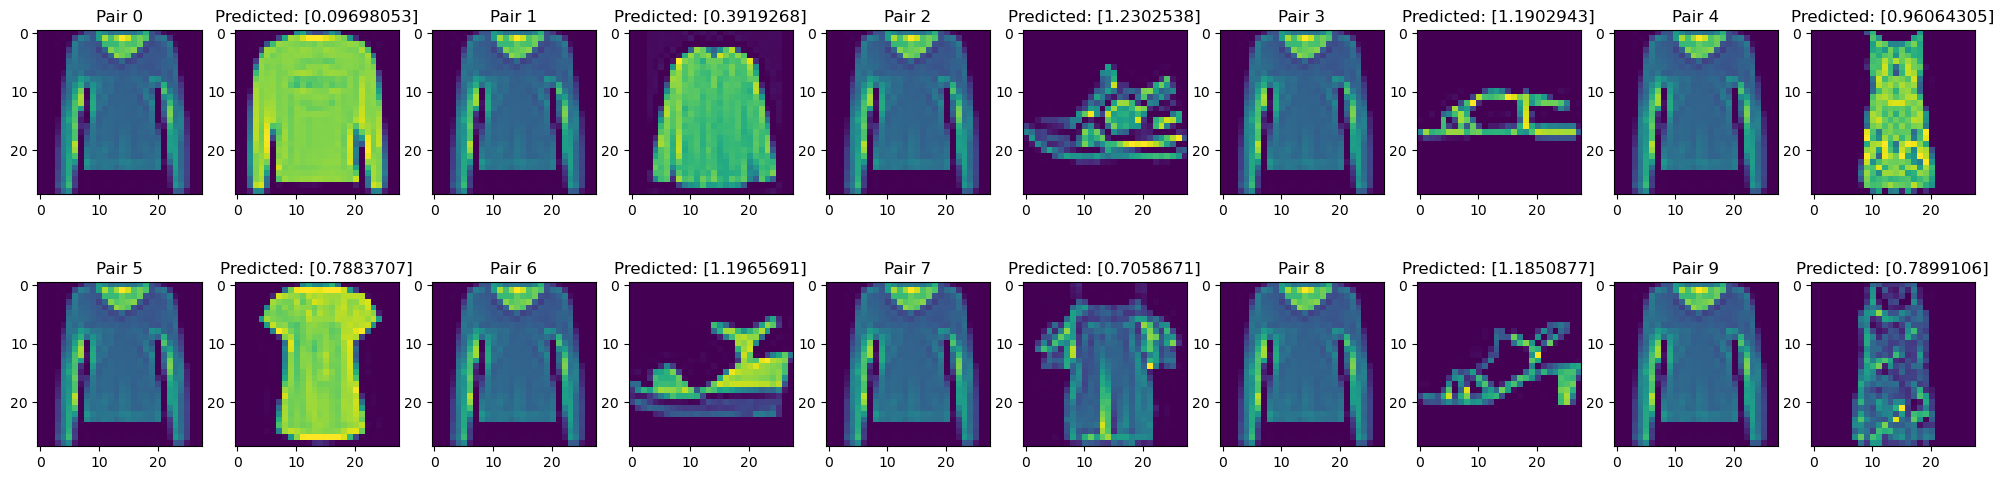

In [12]:
for i in range(10):
    x[0][i,:] = x[0][0,:]

res = siamese_network.predict(x)

fig = plt.figure(figsize=[25, 6])
for i in range(10):
    ax = fig.add_subplot(2, 10, i*2 + 1)
    ax.imshow(x[0][i,:,:,0])
    ax.set_title('Pair ' + str(i))
    
    ax = fig.add_subplot(2, 10, i*2 + 2)
    ax.imshow(x[1][i,:,:,0])    
    ax.set_title('Predicted: ' + str(res[i]))

This looks ok, but it's hard to determine which is more similar of a shoe and a jumper.
If we look at the distributions of the scores we get an idea of what's going on.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


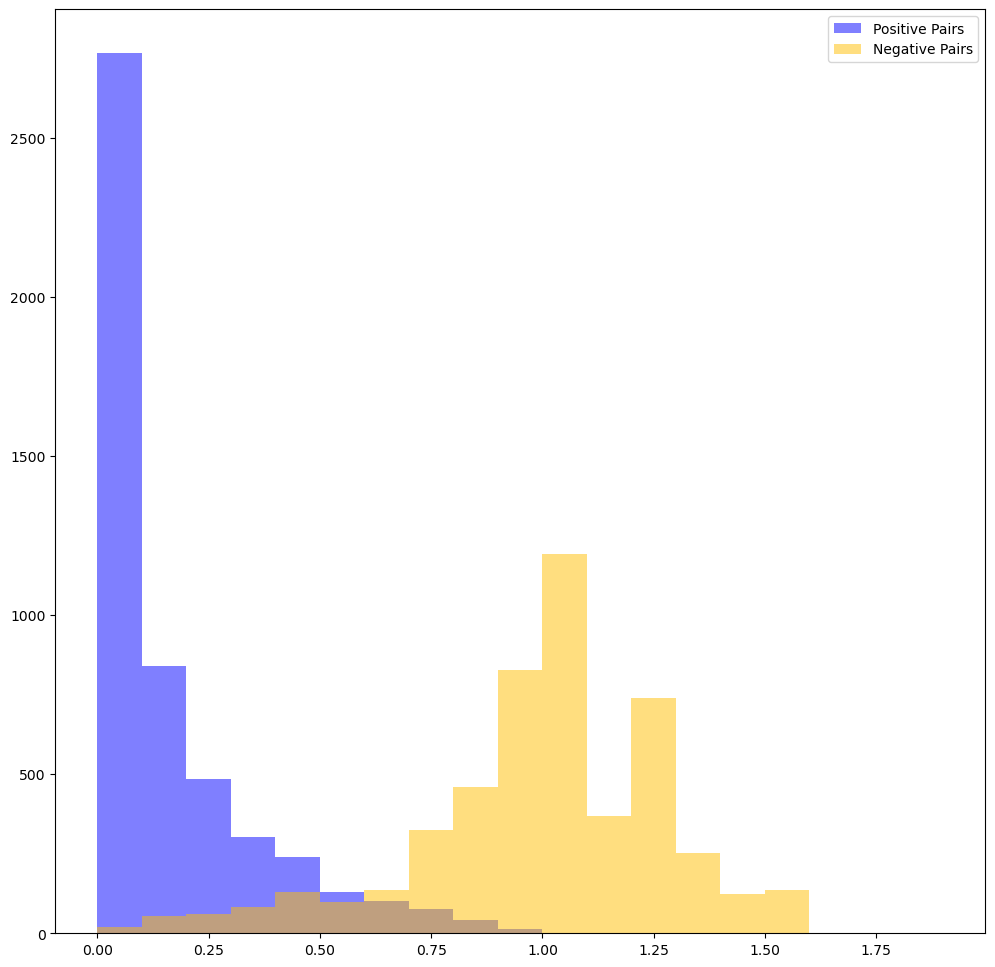

In [13]:
pred = siamese_network.predict(siamese_test_x)
positive_distances = pred[siamese_test_y == 1]
negative_distances = pred[siamese_test_y == 0]
fig = plt.figure(figsize=[12, 12])
ax = fig.add_subplot(1, 1, 1)
ax.hist(positive_distances, numpy.arange(0, 2.0, 0.1), label='Positive Pairs', fc=(0, 0, 1.0, 0.5))
ax.hist(negative_distances, numpy.arange(0, 2.0, 0.1), label='Negative Pairs', fc=(1.0, 0.75, 0, 0.5))
ax.legend();

We can see that, in general, there's a good bit of separation there, but there is also lots of overlap which leads to some of these errors. Ideally, we'd like to get these two distributions further apart, and minimise that overlap as much as possible.

Finally, we'll look at the embeddings.

I0000 00:00:1768953202.358191   12747 service.cc:152] XLA service 0x559a554c65c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768953202.358230   12747 service.cc:160]   StreamExecutor device (0): NVIDIA A16-4Q, Compute Capability 8.6


161/313 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step

I0000 00:00:1768953203.890319   12747 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


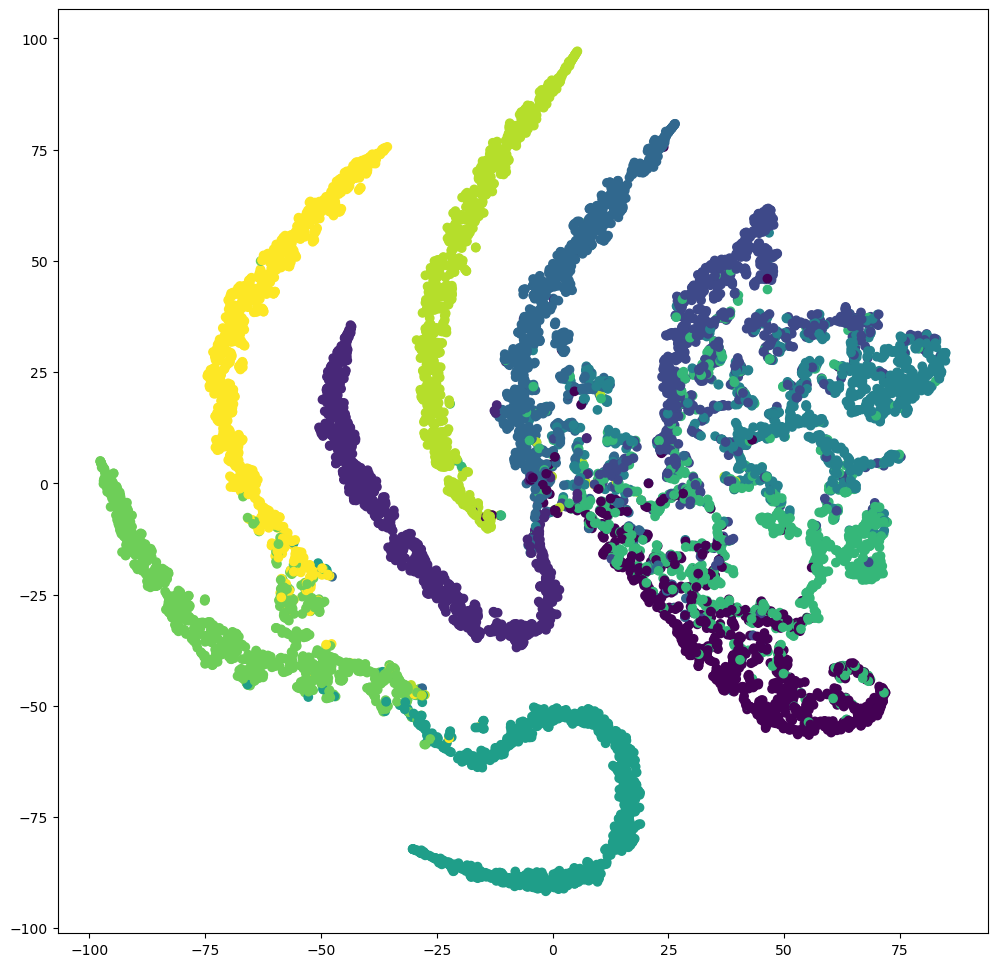

In [14]:
embeddings = base_network.predict(x_test)
tsne_embeddings = TSNE(random_state=4).fit_transform(embeddings)
fig = plt.figure(figsize=[12, 12])
ax = fig.add_subplot(1, 1, 1)
ax.scatter(tsne_embeddings[:,0], tsne_embeddings[:,1], c = y_test.flatten());

This looks much better than what we had with a binary cross entropy loss. While there is still confusion, on the whole there is much better separation going on.

## Final Thoughts
In this example we've used contrastive loss to train our siamese network. Compared to binary cross entropy this means that:
* We don't need a subnetwork, we just train our main brach and try to control how the embedding is generated
* The output of our network is an embedding, which we can compare to the embeddings from other images, letting us work out how similar two things are

There are of course some caveats to all that:
* "Similar" is to some extent whatever the network decides, we don't directly control that as all we give the network is information as to whether the pairs are of the same class or different classes. There is not much nuance in the distances that we feed the network.
* We don't get great separation between distributions that capture the distance between things of the same class, and things of a different class; so the method does still make plenty of errors.

So why would we use this over binary cross entropy? It's simpler for one thing. We just have our base network and loss works directly with that, there is no need to learn a classifier. It also offers flexibility in that it can be used for ranking items based on similarity (even if it's perhaps not amazing at that). For retrieval tasks, where we want to find, for example, all faces like that of a person of interest, this sort of method is much more useful than binary cross entropy - which only tells us if two things are the same.

That said, there are issues with the fact that we need to specify the margin (though we have pretty much mittigated that by using normalisation), and that the network never has to try and pull similar subjects towards each other at the same time as it has to push different subjects apart.